## 2026_Winter_DL_week5_Homework
CNN 실습 예제코드입니다!

이번 5주차 숙제는 총 2가지로 구성되어 있습니다.
- 논문 리뷰 - ResNet : https://arxiv.org/abs/1512.03385
    - 다음 논문을 읽고 팀별로 논문 스터디 및 정리를 준비해주시면 됩니다! (notion 이나 ppt 로 논문 정리 자료 제작 후에 팀별로 git에 업로드 해주세요 :D)

- 코드 과제 (아래 두 가지 중 택1!)
    - 1) (CNN 을 처음 접해보시거나 기초를 더 다지고 싶은 분들께 추천)
        - 아래 실습코드를 그대로 참고하셔도 좋고, 새롭게 짜셔도 좋습니다. 데이터셋은 CIFAR10이 아닌 벤치마크(MNIST, FFHQ, ImageNet)이나 다른 데이터셋을 사용하되, 학습 시간 및 리소스를 적절히 사용할 수 있는 화질을 사용하는 것을 추천 드립니다. 또한, 앞서 배운 regularization, initialization, optimizer 등등 기법을 추가해보시거나, layer를 변형하는 시도를 추가하여 결과를 분석해주세요.
        - example : Earlystopping 추가, Dropoutlayer 추가, batch nomalization 추가, stride 및 padding 변형, Conv layer 추가 및 삭제 등등
    - 2) (이미 CNN 지식이 있는 분들)
        - ResNet 을 논문 "**만**" 읽고 핵심 모듈 코드를 직접 짜보세요! 코드를 보지 않고 conv block이나 layer들을 논문 기반으로 짜보시면 됩니다.(임교수님께서 추천해주신 공부법입니다 ㅎㅎ)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

torch.Size([28, 28])


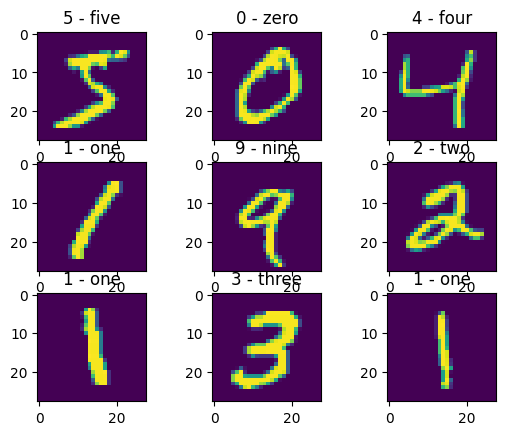

In [2]:
train_data = datasets.MNIST(
    './data/',
    train=True,
    download=True,
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]))

'''
다음과 같이 정의하여 함수형태로 후처리도 가능합니다

transform=transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = data_transform(train_data)
'''


test_data = datasets.MNIST(
    root="../data/",
    train=False,
    download=True,
    transform=transforms.ToTensor())

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_data.data[i])
    plt.title(train_data.classes[train_data.targets[i]])

print(train_data.data[0].shape)
plt.show()

In [3]:
from torch.utils.data import Dataset

class CustomMNIST(Dataset):
    def __init__(self, root, train=True, download=False):
        # self.base_dataset = dataset.load_dataset(path = '')
        self.base_dataset = datasets.MNIST(
            root=root,
            train=train,
            download=download
        )

        self.train = train

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

        self.test_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((32, 32)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])



    def __len__(self):
        return len(self.base_dataset.data)

    def __getitem__(self, idx):
        image = self.base_dataset.data[idx]  # numpy array (H, W, C)
        label = self.base_dataset.targets[idx]

        if self.train:
            image = self.transform(image)
        else:
            image = self.test_transform(image)


        return image, label

# 인스턴스 생성
train_data = CustomMNIST(root='./data/', train=True, download=True)
test_data = CustomMNIST(root='./data/', train=False, download=True)

## Modeling

In [4]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        '''
        nn.Sequential 로 각 레이어를 묶어서 하나의 모델로 정의할 수도 있습니다!

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        '''

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

        # return self.model(x)

In [5]:
class CNN(nn.Module):
    def __init__(self, num_classes): # 클래스의 갯수
        super(CNN, self).__init__()

        # CNN 블럭 정의
        self.block1 = BasicBlock(in_channels=1, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64)
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128)
        self.block4 = BasicBlock(in_channels=256, out_channels=512, hidden_dim=256)

        # classification을 위한 FC 정의
        self.fc1 = nn.Linear(in_features=2048, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.5)


    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x) # 출력모양: (-1, 256, 2, 2)
        x = torch.flatten(x, start_dim=1) # 2차원의 feature map을 1차원으로

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [6]:
from torch.utils.data.dataloader import DataLoader

from torch.optim.adam import Adam


# 데이터로더 정의
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# 학습을 진행할 프로세서 설정
device = "cuda" if torch.cuda.is_available() else "cpu"


print(f"device 정보: {device}")

# CNN 모델 정의
model = CNN(num_classes=10)

# 모델을 device로 보냄
model.to(device)

device 정보: cuda


CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): BasicBlock(
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=4096, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=256,

In [7]:
# Learning rate
lr = 1e-3
best_loss = float('inf')
patience = 5
count = 0

# Optimizer
optim = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss()

# Train loop
for epoch in range(100):

    model.train()
    total_loss = 0

    for data, label in tqdm(train_loader):
        data = data.to(device)
        label = label.to(device)

        optim.zero_grad()

        output = model(data)
        loss = criterion(output, label)

        loss.backward()
        optim.step()

        total_loss += loss.item()

    # 평균 training loss
    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    # Early Stopping
    if avg_loss < best_loss:
        best_loss = avg_loss
        count = 0
    else:
        count += 1

    if count >= patience:
        print("Early Stopping!")
        break

# 모델 저장
torch.save(model.state_dict(), "MNIST.pth")

100%|██████████| 938/938 [00:40<00:00, 23.16it/s]


Epoch 1, Loss: 0.4698


100%|██████████| 938/938 [00:34<00:00, 27.11it/s]


Epoch 2, Loss: 0.0951


100%|██████████| 938/938 [00:34<00:00, 27.27it/s]


...

Epoch 45, Loss: 0.0218


100%|██████████| 938/938 [00:35<00:00, 26.49it/s]


Epoch 46, Loss: 0.0226


100%|██████████| 938/938 [00:34<00:00, 27.19it/s]


Epoch 47, Loss: 0.0212
Early Stopping!


In [8]:
model.load_state_dict(torch.load("MNIST.pth", map_location=device))
model.eval()
num_corr = 0

with torch.no_grad():
    for data, label in tqdm(test_loader):
        output = model(data.to(device))
        preds = output.data.max(1)[1]
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr += corr

    print(f"Accuracy:{num_corr/len(test_data)}")

100%|██████████| 157/157 [00:03<00:00, 39.89it/s]

Accuracy:0.9881


기본 모델 성능: 0.9923 (33에폭)

기본 + weight decay + dropout: 0.9881 (47에폭)

기본 + weight decay + dropout + early stopping: 0.9892 (40에폭)

애초에 MNIST 데이터셋 자체가 쉬운 task라서 모델이 복잡할 필요가 없었던 것 같습니다.
